# Assessing Bicycle Lane Quality Using Smartphone Sensor Data

This notebook contains the complete data analysis pipeline for
classifying bicycle-lane sections as Smooth or Bumpy using
smartphone sensor data.

The analysis includes data loading, preprocessing, feature
extraction, feature selection, supervised and unsupervised
learning, model evaluation, and deployment.

## 0. Environment and Reproducibility
The Python environment and package versions are recorded below to
support reproducibility.

In [1]:
import sys

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.3.5
scikit-learn: 1.9.0
matplotlib: 3.10.0


In [2]:
#Standard library only
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

## Data Collection Metadata

The dataset was collected using smartphone sensor recordings while cycling
on smooth and bumpy bicycle lanes.

The following metadata documents the phone used, phone placement, bicycle,
and route characteristics for each recording.

In [3]:
Collection_info = {'P1':{'Phone':'iphone 15', 'placement':'Vertical on bicycle basket'},
                   'P2':{'Phone':'iphone 13', 'placement':'Vertical on bicycle basket'},
                   'P3':{'Phone':'iphone 17 pro max', 'placement':'Vertical on bicycle basket'}}

Route_info = {'P1_smooth': 'Near Geldropsedijk bus stop','P1_bumpy': 'Eisenhowerlaan',
    'P2_smooth': '','P2_bumpy': '',
    'P3_smooth': '','P3_bumpy': ''}



In [4]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """
    Load accelerometer, gravity, and gyroscope data and combine
    them using their timestamps.
    """

    acc = pd.read_csv(acc_path).rename(
        columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'}
    )

    grav = pd.read_csv(grav_path).rename(
        columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'}
    )

    gyro = pd.read_csv(gyro_path).rename(
        columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'}
    )

    # Check that all recordings have the same number of observations
    if not (len(acc) == len(grav) == len(gyro)):
        raise ValueError("Sensor files have different numbers of rows.")

    # Check timestamp alignment
    if not acc['time'].equals(grav['time']):
        raise ValueError("Accelerometer and gravity timestamps are not aligned.")

    if not acc['time'].equals(gyro['time']):
        raise ValueError("Accelerometer and gyroscope timestamps are not aligned.")

    # Combine the sensor measurements
    df = acc[
        ['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']
    ].copy()

    df[['grav_x', 'grav_y', 'grav_z']] = grav[
        ['grav_x', 'grav_y', 'grav_z']
    ]

    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[
        ['gyro_x', 'gyro_y', 'gyro_z']
    ]

    return df


In [5]:
# Define the location of each participant's recordings

recordings = {
    'P1_smooth': {
        'label': 'smooth',
        'folder': '../data_raw/Smooth/P1'
    },
    'P1_bumpy': {
        'label': 'bumpy',
        'folder': '../data_raw/Bumpy/P1'
    },
    'P2_smooth': {
        'label': 'smooth',
        'folder': '../data_raw/Smooth/P2'
    },
    'P2_bumpy': {
        'label': 'bumpy',
        'folder': '../data_raw/Bumpy/P2'
    },
    'P3_smooth': {
        'label': 'smooth',
        'folder': '../data_raw/Smooth/P3'
    },
    'P3_bumpy': {
        'label': 'bumpy',
        'folder': '../data_raw/Bumpy/P3'
    }
}

In [6]:
merge_recordings = {}

for name, recording in recordings.items():

    folder = recording['folder']

    df = load_and_merge(
        f"{folder}/Accelerometer.csv",
        f"{folder}/Gravity.csv",
        f"{folder}/Gyroscope.csv")

    merge_recordings[name] = df

    print(
        f"{name}: "
        f"{len(df)} rows, "
        f"{df['seconds_elapsed'].max():.1f} seconds"
    )

P1_smooth: 7719 rows, 77.3 seconds
P1_bumpy: 18010 rows, 180.4 seconds
P2_smooth: 12576 rows, 126.8 seconds
P2_bumpy: 19553 rows, 197.2 seconds
P3_smooth: 4763 rows, 47.8 seconds
P3_bumpy: 7583 rows, 76.2 seconds


In [7]:
def recording_quality(key, df):
    t = df['seconds_elapsed'].values
    dt = np.diff(t)

    return {
        'recording': key,
        'rows': len(df),
        'duration_s': round(t[-1] - t[0], 1),
        'effective_hz': round(
            (len(t) - 1) / (t[-1] - t[0]), 1
        ),
        'median_dt_ms': round(
            np.median(dt) * 1000, 2
        ),
        'max_gap_ms': round(
            dt.max() * 1000, 2
        ),
        'missing_values': int(
            df.isna().sum().sum()
        ),
        'duplicate_timestamps': int(
            df['time'].duplicated().sum()
        )
    }


quality = pd.DataFrame(
    [
        recording_quality(name, df)
        for name, df in merge_recordings.items()
    ]
).set_index('recording')

display(quality)

,rows,duration_s,effective_hz,median_dt_ms,max_gap_ms,missing_values,duplicate_timestamps
recording,,,,,,,
P1_smooth,7719,77.3,99.9,10.01,10.64,0,0
P1_bumpy,18010,180.3,99.9,10.01,16.27,0,0
P2_smooth,12576,126.7,99.2,10.08,10.08,0,0
P2_bumpy,19553,197.1,99.2,10.08,10.08,0,0
P3_smooth,4763,47.8,99.6,10.04,10.04,0,0
P3_bumpy,7583,76.1,99.6,10.04,10.67,0,0


In [8]:
print(
    "Total duration: %.1f min" %
    (quality['duration_s'].sum() / 60)
)

print(
    "Total samples per sensor: %d" %
    quality['rows'].sum()
)

Total duration: 11.8 min
Total samples per sensor: 70204


In [9]:
def signal_summary(df):
    # Calculate the overall acceleration magnitude
    magnitude = np.sqrt(
        df['acc_x']**2 +
        df['acc_y']**2 +
        df['acc_z']**2
    )

    return {
        'std': magnitude.std(),
        'p99': np.percentile(magnitude, 99),
        'max': magnitude.max(),
        'pct_samples_above_10': (magnitude > 10).mean() * 100
    }


rows = {}

for name, df in merge_recordings.items():
    rows[name] = signal_summary(df)


label_quality = (
    pd.DataFrame(rows)
    .T
    .round(2)
    .rename(columns={
        'pct_samples_above_10': '% samples > 10 m/s²'
    })
)

display(label_quality)

,std,p99,max,% samples > 10 m/s²
P1_smooth,0.97,4.78,10.23,0.01
P1_bumpy,3.47,16.07,55.13,5.37
P2_smooth,0.93,4.76,8.68,0.00
P2_bumpy,2.68,13.20,47.01,3.41
P3_smooth,0.76,3.83,10.52,0.04
P3_bumpy,2.67,14.24,27.80,3.77


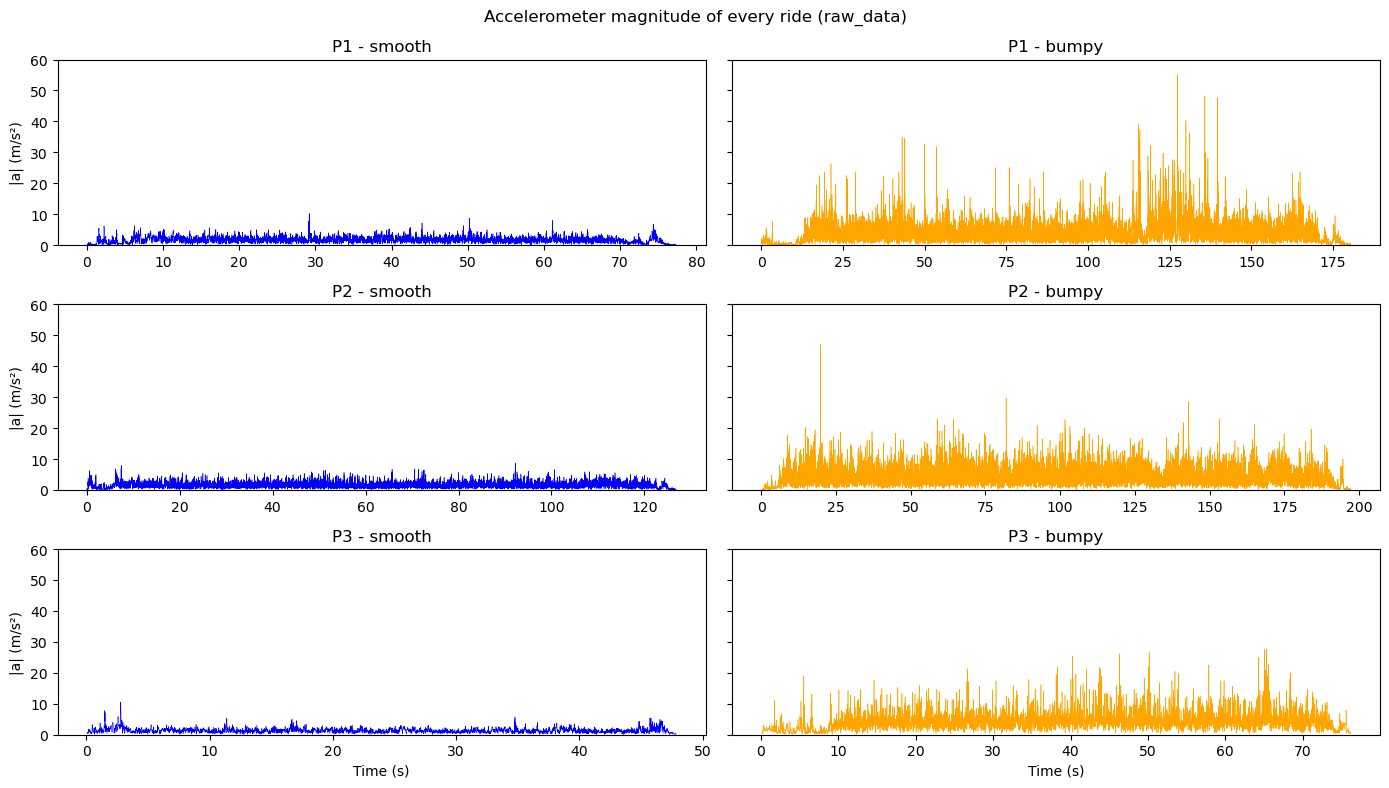

In [10]:
PIDS = ['P1', 'P2', 'P3']

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharey=True)

for i, pid in enumerate(PIDS):

    for j, cls in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{pid}_{cls}']

        mag = np.sqrt(
            df['acc_x']**2 +
            df['acc_y']**2 +
            df['acc_z']**2
        )

        axes[i, j].plot(
            df['seconds_elapsed'],
            mag,
            lw=0.4,
            color='blue' if cls == 'smooth' else 'orange'
        )

        axes[i, j].set_title(f'{pid} - {cls}')
        axes[i, j].set_ylim(0, 60)

        if j == 0:
            axes[i, j].set_ylabel('|a| (m/s²)')

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.suptitle(
    'Accelerometer magnitude of every ride (raw_data)'
)

plt.tight_layout()
plt.show()

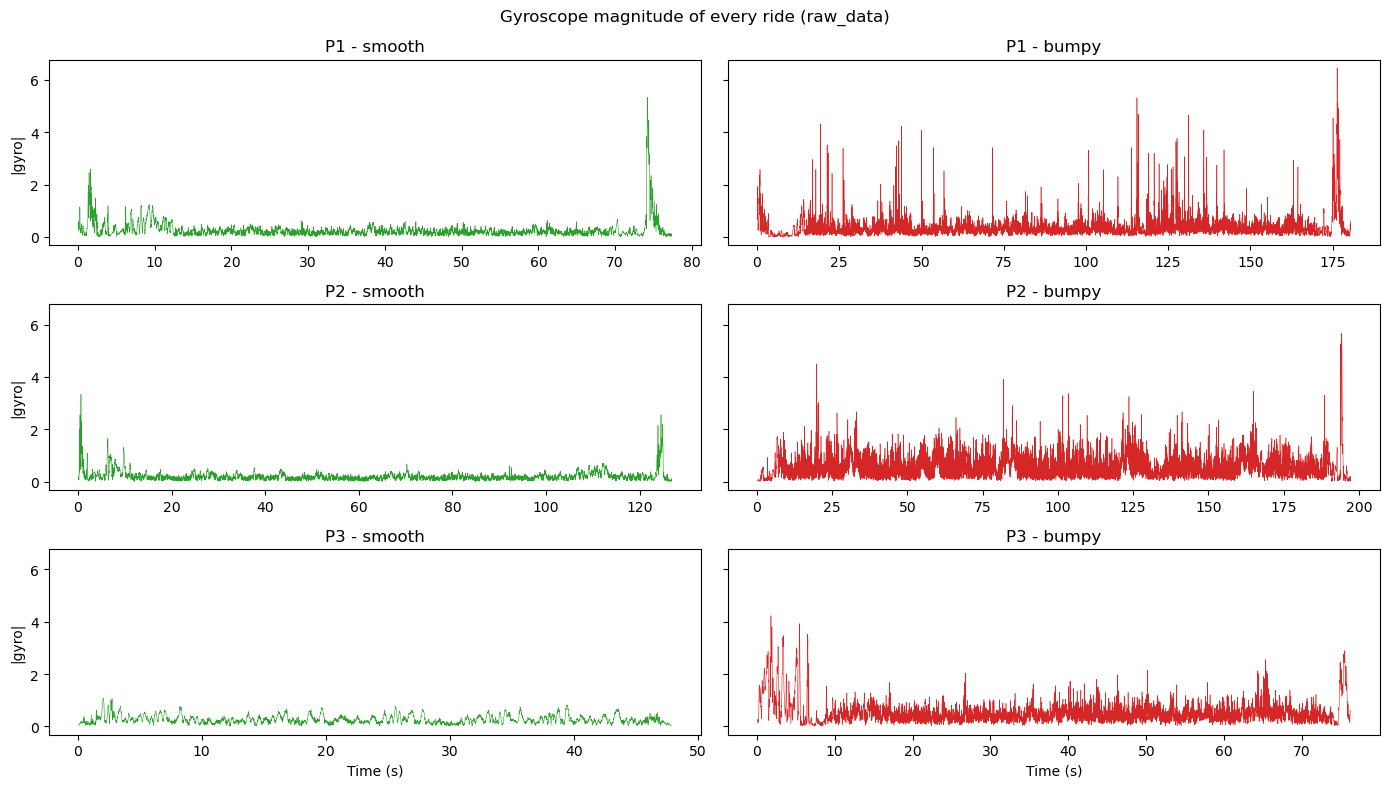

In [11]:
PIDS = ['P1', 'P2', 'P3']

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharey=True)

for i, pid in enumerate(PIDS):

    for j, cls in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{pid}_{cls}']

        gyro_mag = np.sqrt(
            df['gyro_x']**2 +
            df['gyro_y']**2 +
            df['gyro_z']**2
        )

        axes[i, j].plot(
            df['seconds_elapsed'],
            gyro_mag,
            lw=0.4,
            color='tab:green' if cls == 'smooth' else 'tab:red'
        )

        axes[i, j].set_title(f'{pid} - {cls}')

        if j == 0:
            axes[i, j].set_ylabel('|gyro|')

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.suptitle('Gyroscope magnitude of every ride (raw_data)')
plt.tight_layout()
plt.show()

Trim Window

In [12]:
Sampling_freq = 100
steps = 1
window = 2

window_size = Sampling_freq * window
step_size = Sampling_freq * steps

def create_window(df, window_size, step_size):
    windows = []

    for start in range (0, len(df)-window_size+1, step_size):
        end = start + window_size
        windows.append(df.iloc[start:end].copy())

    print(len(windows))
    print(len(windows[0]))
    print("Rows:", len(merge_recordings['P1_smooth']))
    print("Duration:", merge_recordings['P1_smooth']['seconds_elapsed'].iloc[-1])
    print("Windows:", len(windows))
    print("Window size:", len(windows[0]))
    return windows

create_window(merge_recordings['P1_smooth'], window_size, step_size)

for name, df in merge_recordings.items():
    P1_windows = create_window(df, window_size, step_size)
    #print(len(windows[0]))
    print(
        name,
        "| rows:", len(df),
        "| duration:", round(df['seconds_elapsed'].iloc[-1], 2),
        "| windows:", len(P1_windows)
    )

    





76
200
Rows: 7719
Duration: 77.32330200195312
Windows: 76
Window size: 200
76
200
Rows: 7719
Duration: 77.32330200195312
Windows: 76
Window size: 200
P1_smooth | rows: 7719 | duration: 77.32 | windows: 76
179
200
Rows: 7719
Duration: 77.32330200195312
Windows: 179
Window size: 200
P1_bumpy | rows: 18010 | duration: 180.36 | windows: 179
124
200
Rows: 7719
Duration: 77.32330200195312
Windows: 124
Window size: 200
P2_smooth | rows: 12576 | duration: 126.8 | windows: 124
194
200
Rows: 7719
Duration: 77.32330200195312
Windows: 194
Window size: 200
P2_bumpy | rows: 19553 | duration: 197.15 | windows: 194
46
200
Rows: 7719
Duration: 77.32330200195312
Windows: 46
Window size: 200
P3_smooth | rows: 4763 | duration: 47.85 | windows: 46
74
200
Rows: 7719
Duration: 77.32330200195312
Windows: 74
Window size: 200
P3_bumpy | rows: 7583 | duration: 76.18 | windows: 74


Feature extraction

In [13]:
def extract_features(window):
    #magnitude
    acc_mag = np.sqrt(window['acc_x']**2+window['acc_y']**2+window['acc_z']**2)
    grav_mag = np.sqrt(window['grav_x']**2+window['grav_y']**2+window['grav_z']**2)
    gyro_mag = np.sqrt(window['gyro_x']**2+window['gyro_y']**2+window['gyro_z']**2)

    features = {
        # Accelerometer
        'acc_mean': acc_mag.mean(),
        'acc_std': acc_mag.std(),
        'acc_min': acc_mag.min(),
        'acc_max': acc_mag.max(),
        'acc_rms': np.sqrt(np.mean(acc_mag**2)),

        # Gyroscope
        'gyro_mean': gyro_mag.mean(),
        'gyro_std': gyro_mag.std(),
        'gyro_min': gyro_mag.min(),
        'gyro_max': gyro_mag.max(),
        'gyro_rms': np.sqrt(np.mean(gyro_mag**2)),

        # Gravity
        'grav_mean': grav_mag.mean(),
        'grav_std': grav_mag.std(),
        'grav_min': grav_mag.min(),
        'grav_max': grav_mag.max(),
        'grav_rms': np.sqrt(np.mean(grav_mag**2))

    }

    return features

In [14]:
feature_rows = []

for name, df in merge_recordings.items():
    participant , label = name.split('_')
    window = create_window(df, window_size, step_size)

    for window_id,w in enumerate(window):
        feature = extract_features(w)
        feature['participant'] = participant
        feature['label'] = label
        feature['window_id'] = window_id

        feature_rows.append(feature)




76
200
Rows: 7719
Duration: 77.32330200195312
Windows: 76
Window size: 200


179
200
Rows: 7719
Duration: 77.32330200195312
Windows: 179
Window size: 200
124
200
Rows: 7719
Duration: 77.32330200195312
Windows: 124
Window size: 200
194
200
Rows: 7719
Duration: 77.32330200195312
Windows: 194
Window size: 200
46
200
Rows: 7719
Duration: 77.32330200195312
Windows: 46
Window size: 200
74
200
Rows: 7719
Duration: 77.32330200195312
Windows: 74
Window size: 200


In [15]:
features_df = pd.DataFrame(feature_rows)
print(features_df.shape)
print(features_df.head())
print(features_df['label'].value_counts())

(693, 18)
   acc_mean   acc_std   acc_min   acc_max   acc_rms  gyro_mean  gyro_std  \
0  0.886185  1.010505  0.061957  5.520825  1.342140   0.672880  0.631305   
1  1.358877  1.214302  0.068112  6.236351  1.820358   0.725582  0.639781   
2  1.324076  1.122946  0.068112  6.236351  1.734324   0.381427  0.327587   
3  1.173593  0.904788  0.138823  5.025217  1.480496   0.286697  0.225030   
4  0.970845  0.676839  0.091636  3.377678  1.182523   0.190313  0.109840   

   gyro_min  gyro_max  gyro_rms  grav_mean      grav_std  grav_min  grav_max  \
0  0.037141  2.586651  0.921586    9.80665  4.035689e-07  9.806649  9.806651   
1  0.005605  2.586651  0.966304    9.80665  6.089114e-07  9.806648  9.806652   
2  0.005605  1.488414  0.502259    9.80665  7.061292e-07  9.806648  9.806652   
3  0.008595  1.187420  0.364116    9.80665  7.661682e-07  9.806648  9.806652   
4  0.008595  0.495067  0.219599    9.80665  8.015115e-07  9.806648  9.806652   

   grav_rms participant   label  window_id  
0   9.8

In [16]:
feature_columns = [
    'acc_mean', 'acc_std', 'acc_min', 'acc_max', 'acc_rms',
    'gyro_mean', 'gyro_std', 'gyro_min', 'gyro_max', 'gyro_rms',
    'grav_mean', 'grav_std', 'grav_min', 'grav_max', 'grav_rms'
]

X = features_df[feature_columns]
y = features_df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (693, 15)
y shape: (693,)


In [17]:
feature_summary = pd.DataFrame({
    'mean': X.mean(),
    'std': X.std(),
    'min': X.min(),
    'max': X.max()
})

display(feature_summary.round(4))

,mean,std,min,max
acc_mean,3.3310,1.6090,0.3559,8.2665
acc_std,1.9667,1.1345,0.1724,7.2346
acc_min,0.3845,0.2370,0.0233,1.5817
acc_max,12.5875,8.5416,0.9929,55.1315
acc_rms,3.8779,1.9429,0.3952,10.9733
gyro_mean,0.3829,0.2339,0.0688,2.2055
gyro_std,0.2362,0.1939,0.0406,1.7843
gyro_min,0.0494,0.0433,0.0023,0.5007
gyro_max,1.4155,1.0884,0.1854,6.4552
gyro_rms,0.4539,0.2970,0.0819,2.6141


Feature Selection 

In [18]:
feature_selection = [
    'acc_mean', 'acc_std', 'acc_min', 'acc_max', 'acc_rms',
    'gyro_mean', 'gyro_std', 'gyro_min', 'gyro_max', 'gyro_rms'
]

X = features_df[feature_selection]
y = features_df['label']

print(X.shape)
print(y.shape)

(693, 10)
(693,)


Correlation analysis

In [19]:
corr = X.corr()

display(corr.round(2))

,acc_mean,acc_std,acc_min,acc_max,acc_rms,gyro_mean,gyro_std,gyro_min,gyro_max,gyro_rms
acc_mean,1.00,0.94,0.68,0.87,0.99,0.41,0.33,0.32,0.57,0.39
acc_std,0.94,1.00,0.56,0.96,0.97,0.40,0.43,0.25,0.68,0.42
acc_min,0.68,0.56,1.00,0.53,0.65,0.33,0.17,0.31,0.31,0.28
acc_max,0.87,0.96,0.53,1.00,0.91,0.37,0.41,0.23,0.68,0.40
acc_rms,0.99,0.97,0.65,0.91,1.00,0.41,0.37,0.31,0.61,0.41
gyro_mean,0.41,0.40,0.33,0.37,0.41,1.00,0.87,0.60,0.74,0.98
gyro_std,0.33,0.43,0.17,0.41,0.37,0.87,1.00,0.29,0.87,0.95
gyro_min,0.32,0.25,0.31,0.23,0.31,0.60,0.29,1.00,0.34,0.51
gyro_max,0.57,0.68,0.31,0.68,0.61,0.74,0.87,0.34,1.00,0.82
gyro_rms,0.39,0.42,0.28,0.40,0.41,0.98,0.95,0.51,0.82,1.00


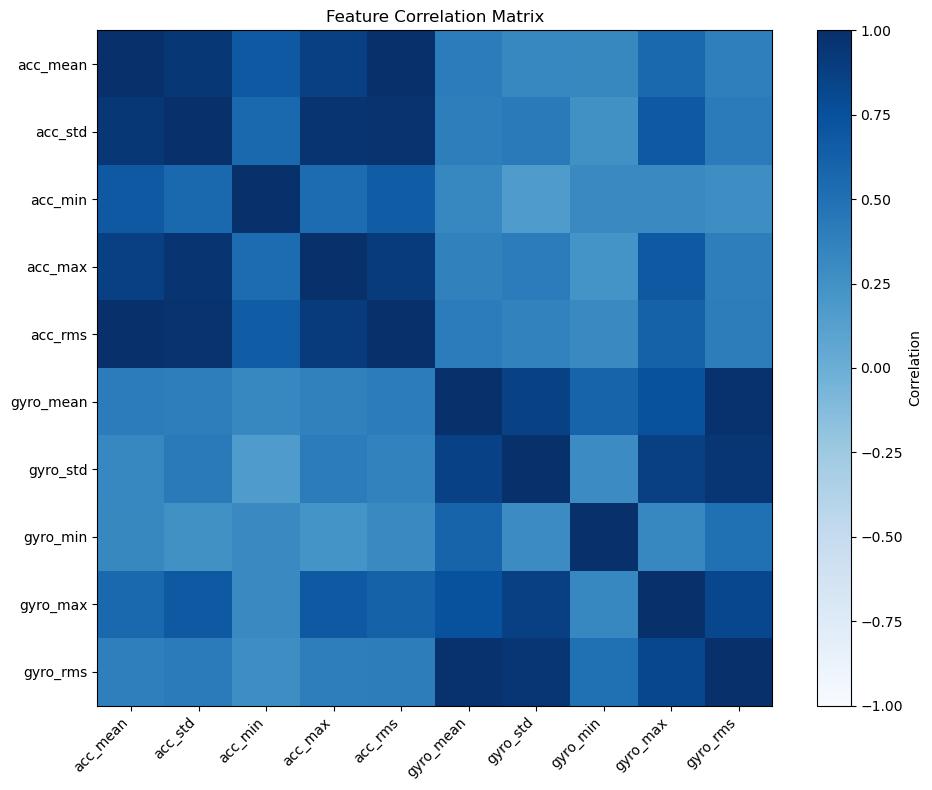

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap='Blues', vmin=-1, vmax=1)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label='Correlation')
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

Mutual Information

In [21]:
from sklearn.feature_selection import  mutual_info_classif

y_numeric = y.map({
    'smooth': 0,
    'bumpy': 1
})

In [22]:
mi_scores = mutual_info_classif(X, y_numeric, random_state=42)

In [23]:
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mutual_information': mi_scores
})

mi_df = mi_df.sort_values(
    'mutual_information',
    ascending=False
)

display(mi_df.round(4))

,feature,mutual_information
4,acc_rms,0.5395
3,acc_max,0.5284
0,acc_mean,0.5230
1,acc_std,0.5110
8,gyro_max,0.4076
6,gyro_std,0.3128
9,gyro_rms,0.2939
5,gyro_mean,0.2862
2,acc_min,0.2828
7,gyro_min,0.1472


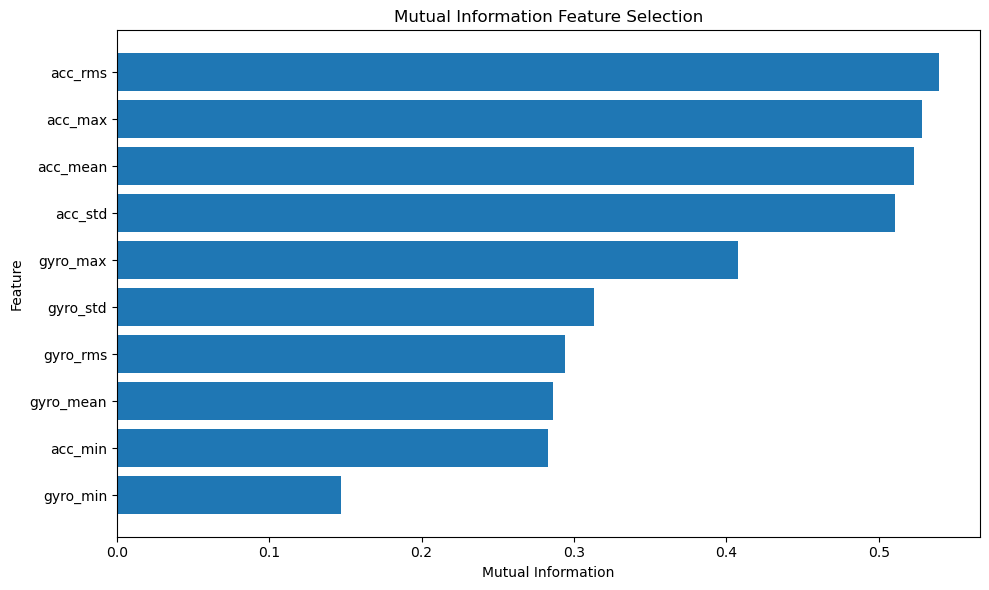

In [24]:
plt.figure(figsize=(10, 6))

plt.barh(
    mi_df['feature'],
    mi_df['mutual_information']
)

plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.title('Mutual Information Feature Selection')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Leave onw group out - P1 + P2 - P3

In [25]:
from sklearn.model_selection import LeaveOneGroupOut

X = features_df[feature_selection]
y = features_df['label']

groups = features_df['participant']

logo = LeaveOneGroupOut()

for train_idx, test_idx in logo.split(X, y, groups):

    train_participants = groups.iloc[train_idx].unique()
    test_participants = groups.iloc[test_idx].unique()

    print(
        "Train:", train_participants,
        "| Test:", test_participants,
        "| Train samples:", len(train_idx),
        "| Test samples:", len(test_idx)
    )

Train: ['P2' 'P3'] | Test: ['P1'] | Train samples: 438 | Test samples: 255
Train: ['P1' 'P3'] | Test: ['P2'] | Train samples: 375 | Test samples: 318
Train: ['P1' 'P2'] | Test: ['P3'] | Train samples: 573 | Test samples: 120


In [26]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

for fold, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups), start=1
):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    y_train_numeric = y_train.map({
        'smooth': 0,
        'bumpy': 1
    })

        # Scale training features for logistic regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Logistic regression estimator
    estimator = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    # RFE
    rfe = RFE(
        estimator=estimator,
        n_features_to_select=5
    )

    rfe.fit(X_train_scaled, y_train_numeric)

    rfe_results = pd.DataFrame({
        'feature': X_train.columns,
        'selected': rfe.support_,
        'ranking': rfe.ranking_
    }).sort_values('ranking')

    print(f"\nFold {fold}")
    display(rfe_results)


Fold 1


,feature,selected,ranking
0,acc_mean,True,1
1,acc_std,True,1
3,acc_max,True,1
4,acc_rms,True,1
8,gyro_max,True,1
6,gyro_std,False,2
7,gyro_min,False,3
2,acc_min,False,4
9,gyro_rms,False,5
5,gyro_mean,False,6



Fold 2


,feature,selected,ranking
0,acc_mean,True,1
1,acc_std,True,1
2,acc_min,True,1
3,acc_max,True,1
4,acc_rms,True,1
8,gyro_max,False,2
6,gyro_std,False,3
5,gyro_mean,False,4
9,gyro_rms,False,5
7,gyro_min,False,6



Fold 3


,feature,selected,ranking
1,acc_std,True,1
3,acc_max,True,1
4,acc_rms,True,1
6,gyro_std,True,1
8,gyro_max,True,1
2,acc_min,False,2
5,gyro_mean,False,3
9,gyro_rms,False,4
7,gyro_min,False,5
0,acc_mean,False,6


Final Features

In [27]:
final_features = [
    'acc_mean',
    'acc_std',
    'acc_max',
    'acc_rms',
    'gyro_max'
]

X_selected = features_df[final_features]
y = features_df['label']

print("Selected features:")
print(final_features)

print("\nShape:", X_selected.shape)

Selected features:
['acc_mean', 'acc_std', 'acc_max', 'acc_rms', 'gyro_max']

Shape: (693, 5)


In [28]:
from sklearn.preprocessing import StandardScaler

X_selected = features_df[final_features]
y = features_df['label']
groups = features_df['participant']

logo = LeaveOneGroupOut()

for fold, (train_idx, test_idx) in enumerate(
    logo.split(X_selected, y_numeric, groups),
    start=1
):

    X_train = X_selected.iloc[train_idx]
    X_test = X_selected.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\nFold {fold}")
    print("Train participant:",
          groups.iloc[train_idx].unique())
    print("Test participant:",
          groups.iloc[test_idx].unique())
    print("X_train:", X_train_scaled.shape)
    print("X_test:", X_test_scaled.shape)


Fold 1
Train participant: ['P2' 'P3']
Test participant: ['P1']
X_train: (438, 5)
X_test: (255, 5)

Fold 2
Train participant: ['P1' 'P3']
Test participant: ['P2']
X_train: (375, 5)
X_test: (318, 5)

Fold 3
Train participant: ['P1' 'P2']
Test participant: ['P3']
X_train: (573, 5)
X_test: (120, 5)


k-Nearest Neighbors (k-NN)

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

knn_results = []
accuracy_score_list = []
cm_list = []

for fold, (train_set, test_set) in enumerate(
    logo.split(X_selected, y_numeric, groups), start=1):

    X_train = X_selected.iloc[train_set]
    X_test = X_selected.iloc[test_set]

    y_train = y_numeric.iloc[train_set]
    y_test = y_numeric.iloc[test_set]

    sc = StandardScaler()

    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)



    model = KNeighborsClassifier(n_neighbors=5)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy_score_list.append(accuracy_score(y_test, y_pred))
    cm_list.append(confusion_matrix(y_test, y_pred))


    knn_results = [{
        'Accuracy':accuracy_score_list,
        'confusion_matrix':cm_list
    }]

knn_results




[{'Accuracy': [0.9137254901960784, 0.9528301886792453, 0.925],
  'confusion_matrix': [array([[ 71,   5],
          [ 17, 162]]),
   array([[120,   4],
          [ 11, 183]]),
   array([[43,  3],
          [ 6, 68]])]}]

Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

knn_results = []
accuracy_score_list = []
cm_list = []

for fold, (train_set, test_set) in enumerate(
    logo.split(X_selected, y_numeric, groups), start=1):

    X_train = X_selected.iloc[train_set]
    X_test = X_selected.iloc[test_set]

    y_train = y_numeric.iloc[train_set]
    y_test = y_numeric.iloc[test_set]

    sc = StandardScaler()

    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)



    model = LogisticRegression()

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy_score_list.append(accuracy_score(y_test, y_pred))
    cm_list.append(confusion_matrix(y_test, y_pred))


    knn_results = [{
        'Accuracy':accuracy_score_list,
        'confusion_matrix':cm_list
    }]

knn_results






[{'Accuracy': [0.9137254901960784, 0.9622641509433962, 0.9833333333333333],
  'confusion_matrix': [array([[ 72,   4],
          [ 18, 161]]),
   array([[120,   4],
          [  8, 186]]),
   array([[44,  2],
          [ 0, 74]])]}]

Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
knn_results = []
accuracy_score_list = []
cm_list = []

for fold, (train_set, test_set) in enumerate(
    logo.split(X_selected, y_numeric, groups), start=1):

    X_train = X_selected.iloc[train_set]
    X_test = X_selected.iloc[test_set]

    y_train = y_numeric.iloc[train_set]
    y_test = y_numeric.iloc[test_set]

    sc = StandardScaler()

    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)



    model = RandomForestClassifier(n_estimators=50, criterion='entropy', max_depth=10)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy_score_list.append(accuracy_score(y_test, y_pred))
    cm_list.append(confusion_matrix(y_test, y_pred))


    knn_results = [{
        'Accuracy':accuracy_score_list,
        'confusion_matrix':cm_list
    }]

knn_results





[{'Accuracy': [0.9176470588235294, 0.9654088050314465, 0.9166666666666666],
  'confusion_matrix': [array([[ 72,   4],
          [ 17, 162]]),
   array([[119,   5],
          [  6, 188]]),
   array([[42,  4],
          [ 6, 68]])]}]

SVM 

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

knn_results = []
accuracy_score_list = []
cm_list = []

for fold, (train_set, test_set) in enumerate(
    logo.split(X_selected, y_numeric, groups), start=1):

    X_train = X_selected.iloc[train_set]
    X_test = X_selected.iloc[test_set]

    y_train = y_numeric.iloc[train_set]
    y_test = y_numeric.iloc[test_set]

    sc = StandardScaler()

    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)



    model = SVC(kernel='rbf')

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy_score_list.append(accuracy_score(y_test, y_pred))
    cm_list.append(confusion_matrix(y_test, y_pred))


    knn_results = [{
        'Accuracy':accuracy_score_list,
        'confusion_matrix':cm_list
    }]

knn_results





[{'Accuracy': [0.9137254901960784, 0.9559748427672956, 0.9416666666666667],
  'confusion_matrix': [array([[ 72,   4],
          [ 18, 161]]),
   array([[120,   4],
          [ 10, 184]]),
   array([[45,  1],
          [ 6, 68]])]}]

------------------------------------------------------------------------------------------------------------------------------

Unsupervised Models

Agglomerative Clustering

In [33]:
from sklearn.cluster import AgglomerativeClustering
sc = StandardScaler()
X_scaled = sc.fit_transform(X_selected)

model = AgglomerativeClustering(n_clusters=2)

clusters = model.fit_predict(X_scaled)

clus_result = pd.crosstab(y, clusters)
print(clus_result)

if clus_result.loc['bumpy', 0] > clus_result.loc['bumpy', 1]:
    predicted = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    predicted = ['smooth' if c == 0 else 'bumpy' for c in clusters]

accuracy = accuracy_score(y, predicted)

print("\nAccuracy:", accuracy)


print("\nConfusion Matrix:")
print(confusion_matrix(y, predicted, labels=['bumpy', 'smooth']))


col_0     0    1
label           
bumpy   421   26
smooth    8  238

Accuracy: 0.950937950937951

Confusion Matrix:
[[421  26]
 [  8 238]]


K means Clustering

In [34]:
from sklearn.cluster import KMeans 
model = KMeans(n_clusters=2, random_state=42)

clusters = model.fit_predict(X_scaled)

clus_result = pd.crosstab(y, clusters)

if clus_result.loc['bumpy', 0] > clus_result.loc['bumpy', 1]:
    predicted = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    predicted = ['smooth' if c == 0 else 'bumpy' for c in clusters]

accuracy = accuracy_score(y, predicted)

print(clus_result)

print("\nAccuracy:", accuracy)


print("\nConfusion Matrix:")
print(confusion_matrix(y, predicted, labels=['bumpy', 'smooth']))

col_0     0    1
label           
bumpy    52  395
smooth  246    0

Accuracy: 0.924963924963925

Confusion Matrix:
[[395  52]
 [  0 246]]


c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

In [35]:
import skfuzzy as fuzz
from sklearn.metrics import accuracy_score, confusion_matrix

# Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T,
    c=2,
    m=2,
    error=0.005,
    maxiter=1000,
    init=None
)

# Assign each sample to the cluster with highest membership
clusters = np.argmax(u, axis=0)

# Compare clusters with actual labels
table = pd.crosstab(y, clusters)
print(table)

# Map clusters to bumpy/smooth
if table.loc['bumpy', 0] > table.loc['bumpy', 1]:
    predicted = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    predicted = ['smooth' if c == 0 else 'bumpy' for c in clusters]

# Accuracy
accuracy = accuracy_score(y, predicted)

print("\nAccuracy:", accuracy)

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(
    y,
    predicted,
    labels=['bumpy', 'smooth']
))

# Fuzzy partition coefficient
print("\nFuzzy Partition Coefficient:", fpc)


col_0     0    1
label           
bumpy    58  389
smooth  246    0

Accuracy: 0.9163059163059163

Confusion Matrix:
[[389  58]
 [  0 246]]

Fuzzy Partition Coefficient: 0.8518318583737331


Gaussian Mixture Model

In [36]:
from sklearn.mixture import GaussianMixture
 
model = GaussianMixture(n_components=2, random_state=42)

clusters = model.fit_predict(X_scaled)

clus_result = pd.crosstab(y, clusters)

if clus_result.loc['bumpy', 0] > clus_result.loc['bumpy', 1]:
    predicted = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    predicted = ['smooth' if c == 0 else 'bumpy' for c in clusters]

accuracy = accuracy_score(y, predicted)

print(clus_result)

print("\nAccuracy:", accuracy)


print("\nConfusion Matrix:")
print(confusion_matrix(y, predicted, labels=['bumpy', 'smooth']))



c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


col_0     0    1
label           
bumpy    10  437
smooth  213   33

Accuracy: 0.937950937950938

Confusion Matrix:
[[437  10]
 [ 33 213]]
